In [ ]:
# 決定木 - データの構造を「木」のような形で表現する、非常に分かりやすく有用なデータ分析手法です。
#回帰問題、分類問題、どちらにも使用できます。有用で便利

# 教師ある学習の一種,決定技は数値ではなくイメージで表される
# 決定木は便利(数値変換の作業がない),回帰分析だと数字よっては対数変換, rootを取ったりする場合がある

In [1]:
import pandas as pd
import numpy as np

#分類問題(分類木)

In [2]:
df_past = pd.read_csv("/content/4-5_user_data.csv")
df_future = pd.read_csv("/content/4-5_user_data_future.csv")

X_name = ['sex', 'student', 'stay time'] #説明変数
y_name = 'registration'

X = df_past[X_name] #Xになるものを指定
y = df_past[y_name] #目的変数

In [ ]:
pip install dtreeviz

In [5]:
from sklearn import tree
from dtreeviz.trees import * #決定木を図として出すライブラリ
import graphviz

In [6]:
dtree = tree.DecisionTreeClassifier(max_depth=2) #引数に木の深さを指定する,3~4段ぐらいがおすすめ,max_depth=2
dtree.fit(X,y) #Xとyを指定する

DecisionTreeClassifier(max_depth=2)

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:3208: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asarray(a).size
/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


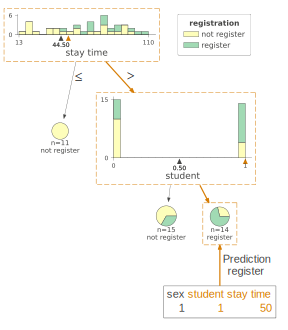

In [18]:
# 結果を図に表す
viz = dtreeviz(dtree,X,y,
               target_name = y_name,
               feature_names = X_name, #Xは一般的に説明変数が複数あるのでsがつく
               class_names = ["not register","register"], # class_name = 何と何に分類するのか指定する
               X = [1,1,50]) #男性(1)で学生(1)でstaytime50秒だったらどうなるのか ->　結果をオレンジの枠で囲ってくれる

viz

# 結果が綺麗に分かれている
# staytimeが44.5秒未満の人は身分関係なく100%登録していない
# staytimeが44.5秒以上の人は登録してくれる人がいる

# そのなかでも
# 学生の場合は約1/3が登録してくれている
# 学生以上のの場合は約2/3が登録してくれている

In [20]:
df_future

,sex,student,stay time
0,0,1,67
1,0,0,80
2,1,0,19
3,0,1,92
4,1,1,56
5,0,0,42
6,0,0,98
7,1,1,78
8,1,0,90
9,0,1,66


In [19]:
# 予測
dtree.predict(df_future) #一気に数字だけ出してもらう

# 0番目は登録してくれそう
# 1番目は登録してくれなそう
# 2番目は登録してくれなそう
# ,,,,

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1])

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:3208: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asarray(a).size
/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


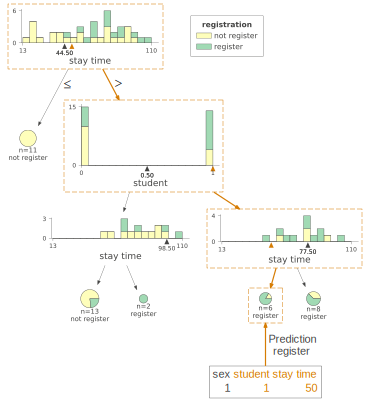

In [22]:
# 深さを3にする場合
dtree = tree.DecisionTreeClassifier(max_depth=3) 
dtree.fit(X,y) 

viz = dtreeviz(dtree,X,y,
               target_name = y_name,
               feature_names = X_name, 
               class_names = ["not register","register"], 
               X = [1,1,50]) 

viz

# 結果を見ながら深さを調整する 
# 性別よりもstaytimeで分類するほうが精度が良い

#回帰問題

In [23]:
df_past = pd.read_csv("/content/4-6_sales.csv")
df_future = pd.read_csv("/content/4-6_sales_future.csv")

X_name = ['temperature', 'price', 'rainy'] #説明変数
y_name = 'sales'

X = df_past[X_name] #Xになるものを指定
y = df_past[y_name] #目的変数

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  "X does not have valid feature names, but"


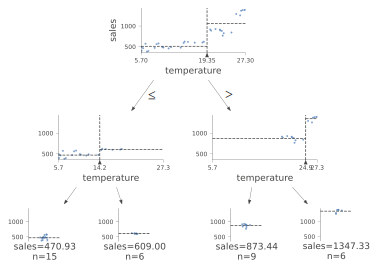

In [32]:
# dtree = tree.DecisionTreeClassifier(max_depth=3) -> 分類 
dtree = tree.DecisionTreeRegressor(max_depth=2)#-> 回帰
dtree.fit(X,y) 

viz = dtreeviz(dtree,X,y,
               target_name = y_name,
               feature_names = X_name
               #class_names = ["not register","register"], 
               #X = [1,1,50]
               ) 
viz

# 気温が19.35以下の以上か未満で分かれる
# ２階層目もtemperatureで分かれる
# 決定木は基本的に2値

In [34]:
df_future

,temperature,price,rainy
0,12.6,180,1
1,18.7,200,0
2,10.2,180,0
3,15.1,240,1
4,20.5,200,0


In [33]:
 # 予測
dtree.predict(df_future)

# temperature:12.6, price:180, rainy:1の場合は470円ぐらい売れる
# temperature:18.7, price:200, rainy:0の場合は609円ぐらい売れる
# ,,,,

# データ分析の手法としてifで結果を得られるため有用

array([470.93333333, 609.        , 470.93333333, 609.        ,
       873.44444444])